# Examen Final — Programación 1 (F12)
## Análisis de Datos Climáticos con la API de Open-Meteo

**Nombre:** Jorge Geovanny Gatica Herrera  
**Carnet:** 202601453  
**Fecha:** 14/05/26  
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos desde la API con `requests` + `pd.DataFrame()` | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el día más caluroso con un ciclo `for` | 10 |
| 2b | Top 5 días más lluviosos con pandas | 10 |
| 3a | Función `clasificar_dia()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_clima()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: el clima de Ciudad de Guatemala

Guatemala tiene un clima subtropical de montaña, con dos estaciones bien definidas:

- **Estación seca** (noviembre – abril): días cálidos, noches frías, precipitación casi nula
- **Estación lluviosa** (mayo – octubre): lluvias frecuentes, temperaturas más estables

Ciudad de Guatemala se ubica a **1 500 m de altitud**, lo que modera las temperaturas
respecto a las zonas costeras.

### Variables climáticas del dataset

| Variable | Unidad | Descripción |
|---|---|---|
| Temperatura máxima | °C | Temperatura más alta registrada en el día |
| Temperatura mínima | °C | Temperatura más baja registrada en el día |
| Precipitación | mm | Agua acumulada en el día (1 mm = 1 L/m²) |
| Viento máximo | km/h | Ráfaga de viento más fuerte del día |

### Clasificación de días por lluvia

| Precipitación | Categoría |
|---|---|
| < 1 mm | Seco |
| 1 – 4.9 mm | Lluvia ligera |
| 5 – 19.9 mm | Lluvia moderada |
| ≥ 20 mm | Lluvia intensa |


---
## El dataset: Open-Meteo Historical Weather

**Fuente:** [open-meteo.com](https://open-meteo.com) — API meteorológica de código abierto,
sin registro ni API key.

Los datos de este examen contienen el **registro climático diario de Ciudad de Guatemala
durante el año 2024** (366 días — 2024 es año bisiesto).

### Cómo cargar los datos

La API devuelve JSON. El código siguiente obtiene los datos y los convierte a DataFrame:

```python
import requests, pandas as pd

URL = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=14.64&longitude=-90.51"
    "&start_date=2024-01-01&end_date=2024-12-31"
    "&daily=temperature_2m_max,temperature_2m_min"
    ",precipitation_sum,wind_speed_10m_max"
    "&timezone=America%2FGuatemala"
)

respuesta = requests.get(URL)
datos     = respuesta.json()
clima     = pd.DataFrame(datos['daily'])
clima['time'] = pd.to_datetime(clima['time'])
```

### Columnas del DataFrame resultante

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | datetime | Fecha del registro |
| `temperature_2m_max` | float | Temperatura máxima diaria (°C) |
| `temperature_2m_min` | float | Temperatura mínima diaria (°C) |
| `precipitation_sum` | float | Precipitación acumulada diaria (mm) |
| `wind_speed_10m_max` | float | Velocidad máxima del viento (km/h) |


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

URL_CLIMA = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=14.64&longitude=-90.51"
    "&start_date=2024-01-01&end_date=2024-12-31"
    "&daily=temperature_2m_max,temperature_2m_min"
    ",precipitation_sum,wind_speed_10m_max"
    "&timezone=America%2FGuatemala"
)

print("Librerias importadas correctamente.")


Librerias importadas correctamente.


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [16]:
# Completa tus datos
NOMBRE = "Jorge Gatica"   # TU NOMBRE AQUI
CARNET = "202601453"         # TU CARNET AQUI

if NOMBRE == "Nombre Apellido" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")


Estudiante : Jorge Gatica
Carnet     : 202601453


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar datos desde la API (10 pts)

La API de Open-Meteo devuelve JSON. Para convertirlo a DataFrame:
1. Usa `requests.get(URL_CLIMA)` para obtener la respuesta
2. Verifica que fue exitosa (`respuesta.ok`)
3. Convierte a diccionario con `.json()`
4. Crea el DataFrame con `pd.DataFrame(datos['daily'])`
5. Convierte la columna `time` a fecha con `pd.to_datetime()`

Guarda el resultado en la variable `clima`.
Luego muestra `.head()`, `.shape`, `.dtypes` y `.isnull().sum()`.

### ¿Por qué verificar la respuesta antes de parsear?

Si el servidor devuelve un error (ej. código 503), el cuerpo de la respuesta
no contiene JSON válido. Llamar `.json()` sin verificar causaría un error.
Siempre verifica `respuesta.ok` antes de continuar.


In [30]:
# Realiza la petición HTTP
respuesta = requests.get(URL_CLIMA, timeout=15)  # TU CÓDIGO AQUÍ — requests.get(URL_CLIMA, timeout=15)

# Verifica que fue exitosa
if not respuesta.ok:
    print(f"Error {respuesta.status_code}: {respuesta.text[:200]}")
    raise SystemExit("No se pudieron obtener los datos. Intenta de nuevo.")

# Convierte la respuesta a diccionario
datos = respuesta.json()  # TU CÓDIGO AQUÍ — respuesta.json()

# Crea el DataFrame desde datos['daily'] y convierte 'time' a datetime
clima = pd.DataFrame(datos['daily'])   # TU CÓDIGO AQUÍ — pd.DataFrame(datos['daily'])
clima['time'] = pd.to_datetime(clima['time'])  # TU CÓDIGO AQUÍ — pd.to_datetime(...)

print(f"Datos cargados: {len(clima)} dias")

# Muestra head(), shape, dtypes e isnull().sum()
# TU CÓDIGO AQUÍ
print("--- Primeras filas ---")
print(clima.head())

print("\n--- Dimensiones del DataFrame ---")
print(clima.shape)

print("\n--- Tipos de datos por columna ---")
print(clima.dtypes)

print("\n--- Conteo de valores nulos ---")
print(clima.isnull().sum())

Datos cargados: 366 dias
--- Primeras filas ---
        time  temperature_2m_max  temperature_2m_min  precipitation_sum  \
0 2024-01-01                23.8                10.7                0.0   
1 2024-01-02                24.1                13.1                0.2   
2 2024-01-03                27.5                12.8                0.1   
3 2024-01-04                24.0                13.9                0.0   
4 2024-01-05                26.5                11.9                0.0   

   wind_speed_10m_max  
0                15.9  
1                18.0  
2                18.5  
3                13.6  
4                23.6  

--- Dimensiones del DataFrame ---
(366, 5)

--- Tipos de datos por columna ---
time                  datetime64[ns]
temperature_2m_max           float64
temperature_2m_min           float64
precipitation_sum            float64
wind_speed_10m_max           float64
dtype: object

--- Conteo de valores nulos ---
time                  0
temperature_2m_max   

### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y `.iterrows()`, imprime la información de los
**primeros 5 días** en este formato:

```
Día 1: 2024-01-01 | max=23.8°C | min=10.7°C | lluvia=0.0 mm
Día 2: 2024-01-02 | max=24.1°C | min=13.1°C | lluvia=0.2 mm
...
```

> Para mostrar la fecha sin la hora puedes usar `fila['time'].date()`.


In [29]:
# Hint: .iterrows() devuelve pares (indice, fila)
# Hint: fila['time'].date() da solo la parte de fecha (sin hora)

contador = 0
for indice, fila in clima.iterrows():
    if contador >= 5:
        break
    # TU CÓDIGO AQUÍ — imprime time, temp_max, temp_min, precipitation_sum
fecha = fila['time'].date()
t_max = fila['temperature_2m_max']
t_min = fila['temperature_2m_min']
lluvia = fila['precipitation_sum']

print(f"Día {contador + 1}: {fecha} | max={t_max}°C | min={t_min}°C | lluvia={lluvia} mm")

contador += 1


Día 1: 2024-12-31 | max=25.0°C | min=14.4°C | lluvia=1.5 mm


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Día más caluroso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna
`temperature_2m_max` y encuentra el día con la **temperatura máxima más alta**.
Guarda el índice y la temperatura máxima encontrada, luego imprime la fecha,
temperatura máxima, mínima y precipitación de ese día.

### Parte b) — Top 5 más lluviosos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 días con mayor precipitación**.
Muestra las columnas `time`, `precipitation_sum`, `temperature_2m_max`
y `temperature_2m_min`.
Luego verifica que el día encontrado en Parte a) aparece en el top 5 de temperaturas.


In [28]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   temp_max   = 0     (para ir guardando la mayor temperatura encontrada)
#   idx_max    = None  (para recordar el índice de esa fila)

temp_max = 0
idx_max  = None

for idx, temp in enumerate(clima['temperature_2m_max']):
    # TU CÓDIGO AQUÍ — actualiza temp_max e idx_max si encontraste una mayor
    if temp > temp_max:
        temp_max = temp
        idx_max = idx


print("Dia mas caluroso:")
print(clima.loc[idx_max, ['time','temperature_2m_max','temperature_2m_min','precipitation_sum']])

# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 dias mas lluviosos:")
# TU CÓDIGO AQUÍ — sort_values por 'precipitation_sum' descendente + head(5)

top_lluvia = clima.sort_values(by='precipitation_sum', ascending=False).head(5)
print(top_lluvia[['time', 'precipitation_sum', 'temperature_2m_max', 'temperature_2m_min']])

print("\nTop 5 dias mas calurosos:")
# TU CÓDIGO AQUÍ — sort_values por 'temperature_2m_max' descendente + head(5)
top_calor = clima.sort_values(by='temperature_2m_max', ascending=False).head(5)
print(top_calor[['time', 'precipitation_sum', 'temperature_2m_max', 'temperature_2m_min']])

Dia mas caluroso:
time                  2024-05-07 00:00:00
temperature_2m_max                   33.3
temperature_2m_min                   15.1
precipitation_sum                     0.0
Name: 127, dtype: object

Top 5 dias mas lluviosos:
          time  precipitation_sum  temperature_2m_max  temperature_2m_min
168 2024-06-17               64.6                19.4                16.4
293 2024-10-20               46.3                21.5                16.5
169 2024-06-18               40.7                21.2                16.1
174 2024-06-23               40.6                23.3                17.1
171 2024-06-20               31.1                19.4                16.6

Top 5 dias mas calurosos:
          time  precipitation_sum  temperature_2m_max  temperature_2m_min
127 2024-05-07                0.0                33.3                15.1
124 2024-05-04                0.0                32.7                15.4
123 2024-05-03                0.0                32.4                

#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos días tiene tu dataset?** El dataset tiene un total de 366.5 días.  
   **¿Cuál fue la temperatura máxima más alta del año?** 33.3 °C  
   **¿En qué fecha ocurrió?** 2024-05-07

2. **¿Cuál fue el día más lluvioso?**  
   Fecha: 2024-06-17 | Precipitación: 64.6 mm | Temperatura máxima ese día: 19.4 °C  
   ¿En qué estación del año ocurrió (seca o lluviosa)? En épocas de lluvia, en la estación de invierno.  
   ¿Tiene sentido según el contexto climático de Guatemala? Justifica.

   *Tu respuesta:* Sí, ya que en fechas por esas mismas fechas empiezan las épocas de lluvia y la llegada del invierno (aunque cada vez se va atrasando más) y normalmente llueve a esa magnitud.

3. ¿El día más caluroso y el más lluvioso coinciden?  
   ¿Qué te dice eso sobre la relación entre temperatura y precipitación en Guatemala?

   *Tu respuesta:* No. El día más caluroso y el día más lluvioso no coinciden, lo cuál tiene sentido. 
   En Guatemala, ocurre que en las estaciones de verano (donde hace más calor) no llueve, lo cuál si concuerda con lo que pasa en el país, igual en viceversa. En los días más lluviosos la temperatura es baja, lo cuáñ tiene sentido.


---
## Ejercicio 3 — Clasificar días con condicionales (25 pts)

### Parte a) — Función `clasificar_dia(precip)` (15 pts)

Escribe una función que reciba la precipitación diaria (float, en mm)
y retorne la categoría según la siguiente escala:

| Precipitación (mm) | Categoría |
|---|---|
| precip < 1 | `'Seco'` |
| 1 ≤ precip < 5 | `'Lluvia ligera'` |
| 5 ≤ precip < 20 | `'Lluvia moderada'` |
| precip ≥ 20 | `'Lluvia intensa'` |

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'tipo_dia'` al DataFrame `clima`.
Luego usa `.groupby('tipo_dia')` para contar cuántos días hay de cada tipo
e imprime el resultado.


In [27]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

def clasificar_dia(precip):
    """Clasifica un dia segun su precipitacion."""
    # TU CÓDIGO AQUÍ
    if precip < 1:
        return 'Seco'
    elif 1 <= precip < 5:
        return 'Luvia ligera'
    elif 5 <= precip < 20:
        return 'Lluvia moderada'
    else:
        return 'Lluvia intensa'


# Prueba tu función — verifica que los resultados son correctos:
for p in [0.0, 0.5, 1.0, 3.5, 5.0, 15.0, 20.0, 45.2]:
    print(f"  precip={p:5.1f} mm  →  {clasificar_dia(p)}")

# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply()
#   clima['tipo_dia'] = clima['precipitation_sum'].apply(clasificar_dia)

# TU CÓDIGO AQUÍ — agregar columna 'tipo_dia'
clima['tipo_dia'] = clima['precipitation_sum'].apply(clasificar_dia)
# TU CÓDIGO AQUÍ — groupby('tipo_dia') para contar días por categoría
resumen_tipos = clima.groupby('tipo_dia')['time'].count()

print("Conteo de días por categoría:")
print(resumen_tipos)

  precip=  0.0 mm  →  Seco
  precip=  0.5 mm  →  Seco
  precip=  1.0 mm  →  Luvia ligera
  precip=  3.5 mm  →  Luvia ligera
  precip=  5.0 mm  →  Lluvia moderada
  precip= 15.0 mm  →  Lluvia moderada
  precip= 20.0 mm  →  Lluvia intensa
  precip= 45.2 mm  →  Lluvia intensa
Conteo de días por categoría:
tipo_dia
Lluvia intensa      16
Lluvia moderada     59
Luvia ligera        88
Seco               203
Name: time, dtype: int64


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad de días | % del año |
   |---|---|---|
   | Seco | 203 | 55.46 % |
   | Lluvia ligera | 88 | 24.04 % |
   | Lluvia moderada | 59 | 16.12 % |
   | Lluvia intensa | 16 | 4.3 % |

2. ¿Qué tipo de día predomina en Guatemala durante 2024?
   ¿Coincide con lo que esperarías dado que tiene estación seca y lluviosa?

   *Tu respuesta:* El día que predomina en Guatemala durante 2024 fueron los días secos. Sí, coincide con lo que se vive, ya que en Guatemala vivimos esa temporada seca a finales de noviembre hasta abril. Aunque el clima predominante sea el seco, las lluvias en Guatemalas son muy intensas en su debida estación.

3. ¿Cuántos días de `'Lluvia intensa'` (≥ 20 mm) hubo?
   ¿En qué meses esperarías que se concentren? ¿Por qué?

   *Tu respuesta:* Hubieron un total de 16 días de lluvia intensa. Los meses en los que espero la mayor parte de lluvias es en la época de Junio y Septiebre, las cuales son meses donde normalmente llueve demasiado y son parte del invierno de Guatemala. 


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_clima(df)` (15 pts)

Escribe una función que reciba el DataFrame `clima` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total_dias'` | número total de días en el dataset |
| `'temp_media'` | temperatura máxima promedio del año (redondeada a 1 decimal) |
| `'temp_record'` | temperatura máxima absoluta del año |
| `'precip_total'` | precipitación total acumulada en el año (mm) |
| `'dias_lluviosos'` | días con precipitación ≥ 5 mm |
| `'mes_mas_caliente'` | número del mes con mayor temperatura máxima promedio |

Luego llama la función con `clima` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas**. Cada una debe tener título y etiquetas en ambos ejes:

1. **Serie de tiempo**: temperatura máxima mensual promedio a lo largo del año
   (agrupa por mes con `.groupby()` y grafica con `plt.plot()` o `sns.lineplot()`)
2. **Scatter plot**: temperatura máxima (`temperature_2m_max`) vs precipitación
   (`precipitation_sum`), coloreado por `tipo_dia` (usa `hue='tipo_dia'`)
3. **Histograma** de precipitación diaria (usa al menos 20 intervalos)


In [26]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max(), .sum() sobre las columnas del DataFrame
# Hint: para 'dias_lluviosos' puedes usar (df['precipitation_sum'] >= 5).sum()
#       o un ciclo for con condicional
# Hint: para 'mes_mas_caliente' agrega una columna 'mes' con df['time'].dt.month
#       luego groupby('mes')['temperature_2m_max'].mean().idxmax()

def analizar_clima(df):
    """
    Resume las estadísticas principales del dataset climático.

    Parámetro:
        df (DataFrame): el DataFrame de datos climáticos diarios.

    Retorna:
        dict con las claves: total_dias, temp_media, temp_record,
                             precip_total, dias_lluviosos, mes_mas_caliente.
    """
    resultado = {
        "total_dias": len(df),  # TU CÓDIGO AQUÍ
        "temp_media": round(df['temperature_2m_max'].mean(), 1),  # TU CÓDIGO AQUÍ
        "temp_record": df['temperature_2m_max'].max(),  # TU CÓDIGO AQUÍ
        "precip_total": round(df['precipitation_sum'].sum(), 2),  # TU CÓDIGO AQUÍ
        "dias_lluviosos": len(df[df['precipitation_sum'] >= 5]),  # TU CÓDIGO AQUÍ
        "mes_mas_caliente": df.groupby(df['time'].dt.month)['temperature_2m_max'].mean().idxmax()  # TU CÓDIGO AQUÍ
    }
    return resultado


# Llama la función e imprime el resumen
resumen = analizar_clima(clima)
for clave, valor in resumen.items():
    print(f"  {clave:<22}: {valor}")


  total_dias            : 366
  temp_media            : 25.8
  temp_record           : 33.3
  precip_total          : 1386.6
  dias_lluviosos        : 75
  mes_mas_caliente      : 5


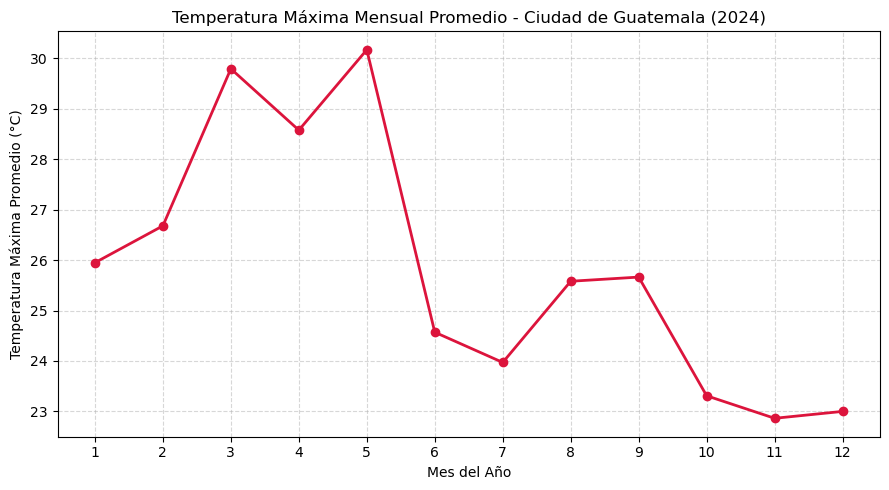

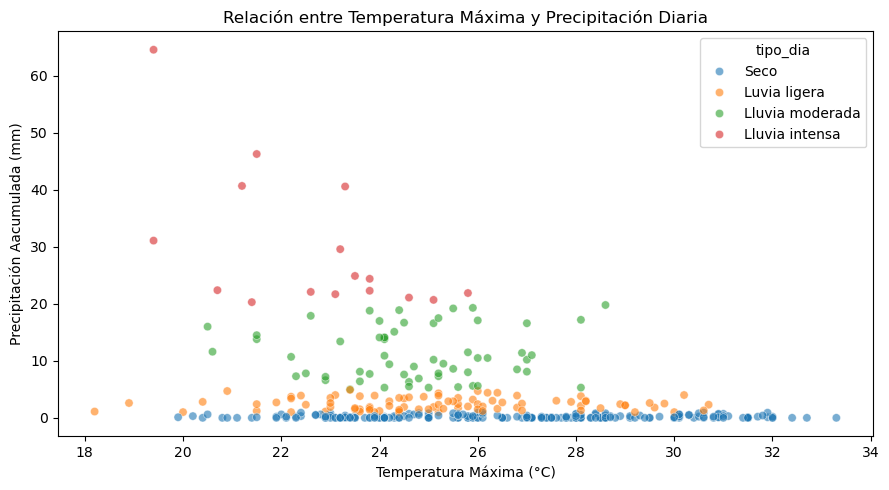

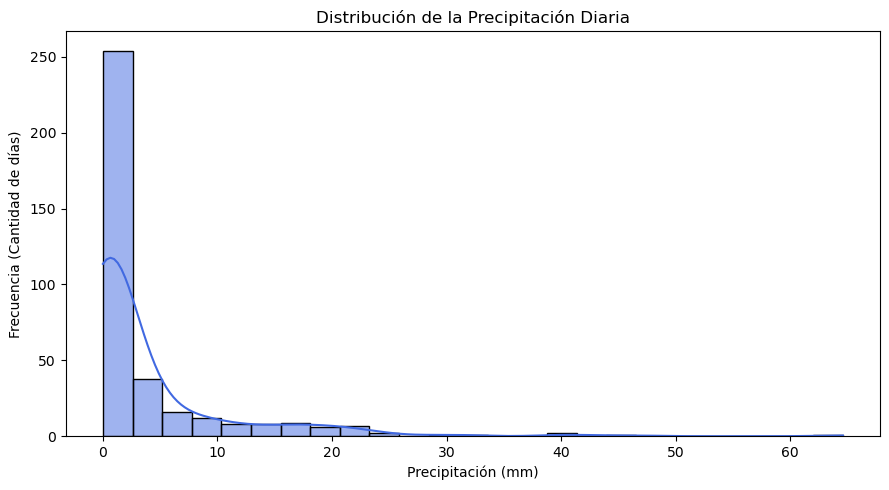

In [25]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────
# Gráfica 1: temperatura máxima mensual promedio (serie de tiempo)
plt.figure(figsize=(9, 5))
# Hint: agrega columna 'mes' y agrupa:
#   clima['mes'] = clima['time'].dt.month
#   temp_mensual = clima.groupby('mes')['temperature_2m_max'].mean()
#   plt.plot(temp_mensual.index, temp_mensual.values, marker='o')
# TU CÓDIGO AQUÍ
clima['mes'] = clima['time'].dt.month
temp_mensual = clima.groupby('mes')['temperature_2m_max'].mean()
plt.plot(temp_mensual.index, temp_mensual.values, marker='o', color='crimson', linewidth=2)

plt.title("Temperatura Máxima Mensual Promedio - Ciudad de Guatemala (2024)")
plt.xlabel("Mes del Año")
plt.ylabel("Temperatura Máxima Promedio (°C)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfica 2: scatter temperatura vs precipitación coloreado por tipo_dia
plt.figure(figsize=(9, 5))
# Hint: sns.scatterplot(data=clima, x='temperature_2m_max',
#                       y='precipitation_sum', hue='tipo_dia', alpha=0.6)
# TU CÓDIGO AQUÍ
sns.scatterplot(data=clima, x='temperature_2m_max', y='precipitation_sum', hue='tipo_dia', alpha=0.6)

plt.title("Relación entre Temperatura Máxima y Precipitación Diaria")
plt.xlabel("Temperatura Máxima (°C)")
plt.ylabel("Precipitación Aacumulada (mm)")
plt.tight_layout()
plt.show()

# Gráfica 3: histograma de precipitación diaria
plt.figure(figsize=(9, 5))
# Hint: sns.histplot(data=clima, x='precipitation_sum', bins=25)
# TU CÓDIGO AQUÍ
sns.histplot(data=clima, x='precipitation_sum', bins=25, color='royalblue', kde=True)

plt.title("Distribución de la Precipitación Diaria")
plt.xlabel("Precipitación (mm)")
plt.ylabel("Frecuencia (Cantidad de días)")
plt.tight_layout()
plt.show()


#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_clima()`, completa:
   - Temperatura máxima media anual: Aproximadamente 25.8  °C  
   - Temperatura máxima record: 30.3 °C  
   - Precipitación total anual: 1386.6 mm  
   - Días lluviosos (≥ 5 mm): 75  
   - Mes más caliente: Marzo (3)

2. **Sobre la serie de tiempo (Gráfica 1):**  
   ¿En qué meses la temperatura fue más alta? ¿Y más baja?
   ¿Puedes distinguir las dos estaciones en la gráfica? Descríbelo.

   *Tu respuesta:* La temperatura más alta se registró en el mes de Mayo y la temperatura más baja se registro en el mes de Noviembre. Sí, se puede distinguir las diferentes estaciones según la gráfica, como bien se dijo, en mayo se registró la temperatura más alta y justo después la temperatura cae drasticamente en Junio, justamente donde empiezan las épocas de lluvias. Después vuelven a subir y finalmente caen debido al invierno.

3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Los días de `'Lluvia intensa'` tienden a tener temperaturas más altas o más bajas?
   ¿Qué relación general observas entre temperatura y precipitación?

   *Tu respuesta:* Los días de lluvia intensa tienden a ser más bajas. Mientras más precipitación hay, más baja la temperatura. Y mientras menos precipitación hay, más alta es la temperatura.

4. **Sobre el histograma de precipitación (Gráfica 3):**  
   ¿La distribución es simétrica? ¿Qué rango de precipitación ocurre con mayor frecuencia?
   ¿Por qué tiene sentido que la mayoría de los días tengan precipitación cercana a cero?

   *Tu respuesta:* No, la distribución no es simétrica. El rango más drecuente es el de 0-2mm (Aproximadamente). Porque no llueven las 24 horas continuamente todos los días, tenemos épocas donde llueve más y menos, pero normalmente la lluvia es casi nula en el diario a vivir.


---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_clima.py` encontrarás tres clases:

- **`RegistroMeteorologico`** — clase base con atributo común: `fecha`
- **`DiaClimatico`** — hereda de `RegistroMeteorologico`, agrega `temp_max`, `temp_min`, `precipitacion` y `viento_max`
- **`RegistroAnual`** — colección de objetos `DiaClimatico` con métodos de consulta

**Paso 1:** Abre `poo_clima.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 5 métodos de `DiaClimatico`: `rango_termico`, `temp_media`, `es_caluroso`, `clasificar`, `descripcion` | 10 |
| b | 3 métodos de `RegistroAnual`: `dia_mas_caluroso`, `dias_por_tipo`, `temp_promedio_anual`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [18]:
from poo_clima import DiaClimatico, RegistroAnual

# Construir el registro anual con todos los días del DataFrame
registro = RegistroAnual("Ciudad de Guatemala", 2024)

for indice, fila in clima.iterrows():
    d = DiaClimatico(
        fecha         = fila['time'].date(),
        temp_max      = fila['temperature_2m_max'],
        temp_min      = fila['temperature_2m_min'],
        precipitacion = fila['precipitation_sum'],
        viento_max    = fila['wind_speed_10m_max'],
    )
    registro.agregar_dia(d)

print(f"Registro creado con {len(registro)} días.\n")

# Muestra los primeros 3 usando __str__ (llama internamente a descripcion())
print("Primeros 3 días:")
for dia in registro._dias[:3]:
    print(" ", dia)

NameError: name 'clima' is not defined

In [13]:
# Día más caluroso del año
mas_caluroso = registro.dia_mas_caluroso()
print("Día más caluroso del año:")
print(" ", mas_caluroso)
print(f"  Rango térmico : {mas_caluroso.rango_termico():.1f} °C")
print(f"  Temperatura media: {mas_caluroso.temp_media():.1f} °C\n")

# Filtrar por tipo
dias_intensos = registro.dias_por_tipo('Lluvia intensa')
print(f"Días de 'Lluvia intensa' en el año: {len(dias_intensos)}\n")

# Resumen completo
registro.resumen()

Día más caluroso del año:
  None


AttributeError: 'NoneType' object has no attribute 'rango_termico'

In [14]:
# Verificación: clasificar() debe coincidir con la columna 'tipo_dia' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 días):")
print(f"  {'fecha':>12}  {'precip':>7}  {'pandas Ej.3':>15}  {'POO clasificar()':>16}  {'':>4}")
print("  " + "─" * 64)

for i, (indice, fila) in enumerate(clima.head(10).iterrows()):
    d = DiaClimatico(fila['time'].date(), fila['temperature_2m_max'],
                     fila['temperature_2m_min'], fila['precipitation_sum'],
                     fila['wind_speed_10m_max'])
    cat_poo    = d.clasificar()
    cat_pandas = fila['tipo_dia']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {str(fila['time'].date()):>12}  {fila['precipitation_sum']:>7.1f}  "
          f"{cat_pandas:>15}  {cat_poo:>16}  {marca}")

Verificación POO vs. pandas (primeros 10 días):
         fecha   precip      pandas Ej.3  POO clasificar()      
  ────────────────────────────────────────────────────────────────


NameError: name 'clima' is not defined

#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `RegistroMeteorologico` y `DiaClimatico`?
   ¿Por qué `DiaClimatico.__init__` llama a `super().__init__(fecha)`?

   *Tu respuesta:* ___

2. El método `clasificar()` de `DiaClimatico` usa la misma lógica que la función
   `clasificar_dia()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* ___

3. Según `registro.resumen()`:
   - ¿En qué fecha fue el día más caluroso? ___
   - ¿Cuántos días de `'Lluvia intensa'` hubo en el año? ___
   - Temperatura máxima promedio anual: ___ °C

   *Tu respuesta:* ___

4. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* ___

---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿En qué meses fue más caluroso/lluvioso el año 2024 en Guatemala?
  ¿Coincide con lo que esperarías de las estaciones seca y lluviosa?

El mes más caluroso de Guatemala fue en Mayo y el más lluvioso fue en Junio. Sí coincide con lo que esoeraria en el clima de Guatemala, concuerda muy bien con las épocas.

- ¿Qué tipo de día (`tipo_dia`) predominó durante el año?



- ¿Qué relación observas entre temperatura y precipitación en el scatter plot?

Mientras más llueve, es donde la temperatura se desploma y queda una temperatura baja, mientras que cuando no llueve, la temperatura se alza y empieza el calor.


---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Cómo fue el clima de Ciudad de Guatemala durante 2024 según tu análisis?

El clima de Guatemala en el 2024 fue muy caluroso al parecer, en Mayo se disparó la temperatura promedio máxima y a su vez, fue un año con lluvias fuertes, 16 para ser más precisos. Lo que indica que Guatemala puede sufrir de calores intensos y orecipitaciones poderosas que pueden peligrosas para algunas familias guatemaltecas. También que confirmamos que el auge del verano en Guatemala es en Mayo y en Junio empiezan las épocas de lluvia y al final terminando con el invierno.

- ¿Qué patrones estacionales puedes identificar en los datos?

Los patrones estacionales que más se pueden distinguir según todo este proceso (y los cuales estamos va de mencionar a cada rato), es el inicio del verano y su punto más fuerte, siendo este en Mayo y el inicio de las épocas de lluvia en Julio, el inicio del invierno por Octubre y otra vez todo el ciclo.

- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

*(Escribe aquí tu respuesta — mínimo 5 oraciones)*




---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [17]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL B")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...

        SELLO DE ENTREGA -- EXAMEN FINAL B
  Estudiante   : Jorge Gatica
  Carnet       : 202601453
  Fecha/Hora   : 2026-05-17 01:55:51 UTC
  ISS Latitud  : -48.5453 deg
  ISS Longitud : +73.9979 deg
  ISS Hora UTC : 2026-05-17 01:55:51 UTC


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
